# Day 4B: BERT, RoBERTa, and Fine-Tuning for Text Classification

This is the advanced transformer companion to Day 4. It shows how BERT-style models are used for classification and how fine-tuning differs from classical feature engineering.

The model cells are controlled by flags. In the distributed student notebook, download-heavy cells are disabled by default. Install the optional transformer requirements, enable one flag at a time, and download model weights before class if possible.

By the end you should be able to:

1. Explain how transformer tokenization differs from spaCy/scikit-learn tokenization.
2. Run a pretrained transformer classifier and discuss domain mismatch.
3. Distinguish frozen transformer features from full fine-tuning.
4. Fine-tune BERT/RoBERTa-style sequence classifiers on local SMS spam data.
5. Compare transformer models fairly with a TF-IDF logistic-regression baseline.
6. Diagnose learning curves and confident classification errors.
7. Report transformer models with enough detail for reproducibility.

In [1]:
from pathlib import Path
import importlib.util
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

pd.set_option('display.max_colwidth', 160)
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

## Setup flags

The first run of a Hugging Face model will download weights. For a live class, do this before the session if possible.

Recommended class setting:

- Use `distilbert-base-uncased` for a faster CPU/GPU demonstration.
- Show that switching to `bert-base-uncased` or `roberta-base` changes the model/tokenizer but not the training logic.
- The fine-tuning example now uses the full deduplicated SMS dataset. If classroom time is tight, keep the student-release flags off and run the heavy sections selectively.

In [2]:
RUN_TRANSFORMER_TOKENIZATION = True
RUN_PRETRAINED_PIPELINE = True
RUN_FROZEN_FEATURES = True
RUN_FINE_TUNING = True

# Fast classroom default. Replace with 'bert-base-uncased' or 'roberta-base' to demonstrate those architectures.
MODEL_NAME = 'distilbert-base-uncased'
ALTERNATIVE_MODELS = ['bert-base-uncased', 'roberta-base']

TRANSFORMERS_AVAILABLE = importlib.util.find_spec('transformers') is not None
TORCH_AVAILABLE = importlib.util.find_spec('torch') is not None

print('transformers available:', TRANSFORMERS_AVAILABLE)
print('torch available:', TORCH_AVAILABLE)
print('model selected:', MODEL_NAME)

transformers available: True
torch available: True
model selected: distilbert-base-uncased


In [3]:
def find_data_dir():
    candidates = [Path('../data'), Path('materials/data'), Path('data')]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError('Could not find the course data directory.')

DATA_DIR = find_data_dir()
DATA_DIR

PosixPath('../data')

## 1. Build comparable train, validation, and test sets

We use the local SMS Spam Collection because it is short, labeled, imbalanced, and easy to interpret.

The split happens **after** removing exact duplicate messages, so the same text cannot appear in both training and test data. We then use the full deduplicated dataset:

- a full stratified training set for every model;
- a full stratified validation set for model selection during fine-tuning;
- a full stratified test set with the dataset's natural spam prevalence;
- a balanced diagnostic slice of the test set, used only to show how prevalence changes evaluation.

The main model comparison now uses all available training examples. The balanced diagnostic test is not a replacement for the full test set; it is a teaching device for separating class-separation performance from base-rate effects.

In [4]:
sms = pd.read_csv(DATA_DIR / 'sms_spam.csv')
sms = sms[['text', 'label', 'is_spam']].dropna().copy()
sms = sms.rename(columns={'label': 'class_name', 'is_spam': 'label'})
sms['label'] = sms['label'].astype(int)
sms['class_name'] = sms['class_name'].str.lower()

n_duplicates = sms.duplicated(subset='text').sum()
sms = sms.drop_duplicates(subset='text').reset_index(drop=True)
print(f'Removed {n_duplicates} exact duplicate messages before splitting.')


def sample_per_class(frame, class_col, n, seed):
    pieces = []
    for _, group in frame.groupby(class_col):
        pieces.append(group.sample(min(len(group), n), random_state=seed))
    return (
        pd.concat(pieces, ignore_index=True)
        .sample(frac=1, random_state=seed)
        .reset_index(drop=True)
    )


comparison_train, temp_pool = train_test_split(
    sms,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=sms['label']
)
comparison_valid, comparison_test = train_test_split(
    temp_pool,
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=temp_pool['label']
)

comparison_train = comparison_train.reset_index(drop=True)
comparison_valid = comparison_valid.reset_index(drop=True)
comparison_test = comparison_test.reset_index(drop=True)

minority_test_n = comparison_test['class_name'].value_counts().min()
balanced_diagnostic_test = sample_per_class(
    comparison_test,
    'class_name',
    minority_test_n,
    RANDOM_SEED
)


def result_row(model_name, evaluation_set, y_true, y_pred):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', zero_division=0
    )
    return {
        'model': model_name,
        'evaluation_set': evaluation_set,
        'n_test': len(y_true),
        'spam_prevalence': np.mean(y_true),
        'accuracy': accuracy_score(y_true, y_pred),
        'precision_spam': precision,
        'recall_spam': recall,
        'f1_spam': f1,
    }


model_results = []

split_summary = pd.DataFrame([
    {'split': 'full train', 'n': len(comparison_train), 'spam_prevalence': comparison_train['label'].mean()},
    {'split': 'full validation', 'n': len(comparison_valid), 'spam_prevalence': comparison_valid['label'].mean()},
    {'split': 'full test', 'n': len(comparison_test), 'spam_prevalence': comparison_test['label'].mean()},
    {'split': 'balanced diagnostic test', 'n': len(balanced_diagnostic_test), 'spam_prevalence': balanced_diagnostic_test['label'].mean()},
])
display(split_summary)
comparison_train[['text', 'class_name', 'label']].head()

Removed 414 exact duplicate messages before splitting.


,split,n,spam_prevalence
0,full train,3612,0.124308
1,full validation,774,0.125323
2,full test,774,0.124031
3,balanced diagnostic test,192,0.500000


,text,class_name,label
0,Me i'm not workin. Once i get job...,ham,0
1,"I haven't forgotten you, i might have a couple bucks to send you tomorrow, k? I love ya too",ham,0
2,Are you there in room.,ham,0
3,"Dear,shall mail tonite.busy in the street,shall update you tonite.things are looking ok.varunnathu edukkukayee raksha ollu.but a good one in real sense.",ham,0
4,Do u noe how 2 send files between 2 computers?,ham,0


## 2. Classical baseline: TF-IDF + logistic regression

Always keep a simple baseline. If BERT barely beats this, that is a substantive result, not a failure.

The baseline receives exactly the same full training documents as the transformer models. We evaluate it on the full natural-prevalence test set and on the balanced diagnostic slice.

              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       678
        spam       0.90      0.93      0.91        96

    accuracy                           0.98       774
   macro avg       0.94      0.96      0.95       774
weighted avg       0.98      0.98      0.98       774



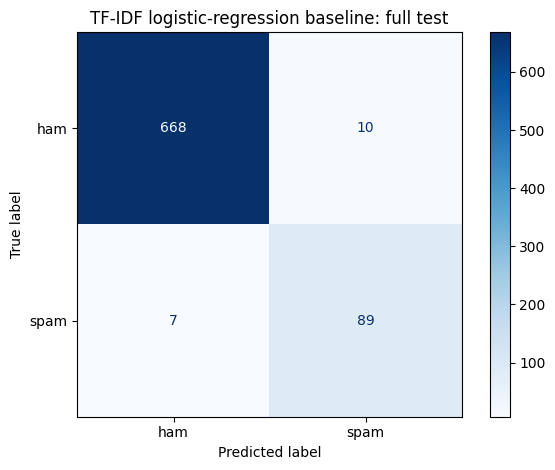

In [5]:
baseline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', min_df=2, max_features=8000, ngram_range=(1, 2))),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_SEED))
])

baseline.fit(comparison_train['text'], comparison_train['label'])

baseline_full_pred = baseline.predict(comparison_test['text'])
baseline_balanced_pred = baseline.predict(balanced_diagnostic_test['text'])

model_results.extend([
    result_row('TF-IDF + logistic regression', 'full test', comparison_test['label'], baseline_full_pred),
    result_row('TF-IDF + logistic regression', 'balanced diagnostic test', balanced_diagnostic_test['label'], baseline_balanced_pred),
])

print(classification_report(
    comparison_test['label'],
    baseline_full_pred,
    target_names=['ham', 'spam']
))
ConfusionMatrixDisplay.from_predictions(
    comparison_test['label'],
    baseline_full_pred,
    display_labels=['ham', 'spam'],
    cmap='Blues'
)
plt.title('TF-IDF logistic-regression baseline: full test')
plt.tight_layout()

## 3. Transformer tokenization

BERT-style models do not use spaCy tokens. They use model-specific subword tokenizers. BERT uses WordPiece; RoBERTa uses a byte-level BPE tokenizer. This matters because the unit of representation changes.

### Methodology formulas: transformer classification and fine-tuning

A transformer tokenizer maps text to a sequence of token ids, usually with special tokens:

$$x_i \rightarrow ([\mathrm{CLS}], t_1, \ldots, t_m, [\mathrm{SEP}]).$$

Self-attention builds contextual representations by comparing queries, keys, and values:

$$\mathrm{Attention}(Q,K,V)=\mathrm{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right)V.$$

For sequence classification, BERT-style models usually classify from the contextual representation of the special classification token:

$$p(y_i \mid x_i)=\mathrm{softmax}(W h_{i,[\mathrm{CLS}]} + b).$$

Fine-tuning minimizes cross-entropy on labeled examples:

$$\mathcal{L}(\Theta)=-\frac{1}{N}\sum_{i=1}^N \log p_\Theta(y_i \mid x_i).$$

The frozen-feature workflow keeps transformer parameters fixed and trains a small classifier on pooled embeddings, for example

$$\bar{h}_i = \frac{1}{m_i}\sum_{t=1}^{m_i} h_{it}, \qquad P(y_i=1\mid \bar{h}_i)=\sigma(\eta_0+\bar{h}_i^\top\eta).$$

The full fine-tuning workflow updates both the classifier head and the transformer weights:

$$\Theta_{r+1}=\Theta_r - \lambda \nabla_\Theta \mathcal{L}(\Theta_r).$$


In [6]:
if RUN_TRANSFORMER_TOKENIZATION:
    if not TRANSFORMERS_AVAILABLE:
        raise ImportError('Install transformers first: pip install -r materials/requirements-transformers.txt')

    from transformers import AutoTokenizer

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    example = comparison_test.iloc[0]['text']
    encoded = tokenizer(example, truncation=True, max_length=64)

    token_table = pd.DataFrame({
        'token_id': encoded['input_ids'],
        'token': tokenizer.convert_ids_to_tokens(encoded['input_ids']),
        'attention_mask': encoded['attention_mask']
    })
    display(example)
    display(token_table.head(40))
else:
    print('Tokenization demo skipped. Set RUN_TRANSFORMER_TOKENIZATION=True after installing transformers and model weights.')

/Users/petrotolochko/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'Sez, hows u & de arab boy? Hope u r all good give my love 2 evry1 love ya eshxxxxxxxxxxx'

,token_id,token,attention_mask
0,101,[CLS],1
1,7367,se,1
2,2480,##z,1
3,1010,",",1
4,2129,how,1
5,2015,##s,1
6,1057,u,1
7,1004,&,1
8,2139,de,1
9,5424,arab,1


### Additional demo: spaCy vs. BERT/RoBERTa tokenization

Transformer models use subword tokenization, so the tokens seen by the model are not the same as linguistic words from spaCy. This comparison is useful before interpreting transformer inputs.

,tokenizer,position,token
0,spaCy words,0,URGENT
1,spaCy words,1,!
2,spaCy words,2,You
3,spaCy words,3,won
4,spaCy words,4,a
5,spaCy words,5,free
6,spaCy words,6,prize
7,spaCy words,7,.
8,spaCy words,8,Reply
9,spaCy words,9,STOP


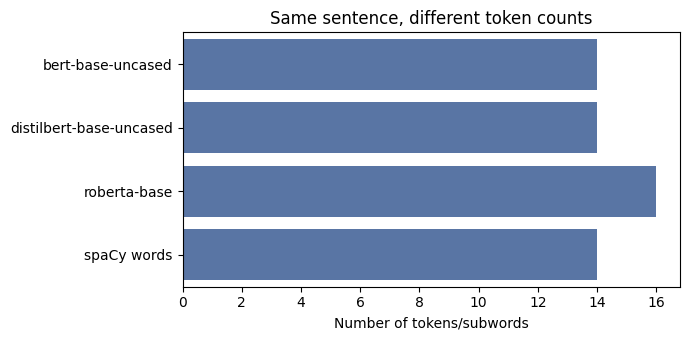

In [7]:
if RUN_TRANSFORMER_TOKENIZATION:
    if not TRANSFORMERS_AVAILABLE:
        raise ImportError('Install transformers first: pip install -r materials/requirements-transformers.txt')

    import spacy
    from transformers import AutoTokenizer

    compare_text = "URGENT! You won a free prize. Reply STOP to opt out."
    spacy_tokenizer = spacy.blank('en')

    rows = []
    for position, token in enumerate(spacy_tokenizer(compare_text)):
        rows.append({'tokenizer': 'spaCy words', 'position': position, 'token': token.text})

    transformer_names = []
    for model_name in [MODEL_NAME] + ALTERNATIVE_MODELS:
        if model_name not in transformer_names:
            transformer_names.append(model_name)

    for model_name in transformer_names:
        try:
            tok = AutoTokenizer.from_pretrained(model_name)
            pieces = tok.tokenize(compare_text)
            for position, token in enumerate(pieces):
                rows.append({'tokenizer': model_name, 'position': position, 'token': token})
        except Exception as exc:
            rows.append({'tokenizer': model_name, 'position': 0, 'token': f'Could not load tokenizer: {type(exc).__name__}'})

    tokenization_comparison = pd.DataFrame(rows)
    display(tokenization_comparison)

    token_counts = tokenization_comparison.groupby('tokenizer').size().reset_index(name='n_tokens')
    plt.figure(figsize=(7, 3.5))
    sns.barplot(data=token_counts, x='n_tokens', y='tokenizer', color='#4C72B0')
    plt.title('Same sentence, different token counts')
    plt.xlabel('Number of tokens/subwords')
    plt.ylabel('')
    plt.tight_layout()
else:
    print('Tokenization comparison skipped. Set RUN_TRANSFORMER_TOKENIZATION=True to run it.')

## 4. Pretrained sentiment classifier as a domain check

This section uses a model that was already fine-tuned on sentiment data and evaluates it on the local TweetEval sentiment sample. It is useful for explaining the difference between pretraining, task fine-tuning, and domain fit. It is not a spam detector.

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 15709.57it/s]

              precision    recall  f1-score   support

    negative       0.83      0.94      0.88        66
    positive       0.91      0.76      0.83        54

    accuracy                           0.86       120
   macro avg       0.87      0.85      0.85       120
weighted avg       0.86      0.86      0.86       120



,text,label_name,transformer_polarity,transformer_score
2397,"""After the exciting news of """"U2"""" announcing Irish dates in November, here's an interesting little fact, :) When U2...",positive,positive,0.977178
1416,RVP is getting the Hulk Hogan treatment by Man Utd. No mention of him at all. Pathetic considering he won us our 20th title.,negative,negative,0.998962
1313,"""Kane finding form at the right time, ready to score twice against Sunderland on Sunday...""",positive,positive,0.999170
233,"A good song is like a ""psychic refreshment."" (from Leonard Cohen) ... Oh yes! It really can be like that.",positive,positive,0.999734
1923,Karthikeyan in 22nd is already being warned by his HRT engineer that he needs to cool the brakes\u002c with 53 laps still to go. #F1,negative,negative,0.998870


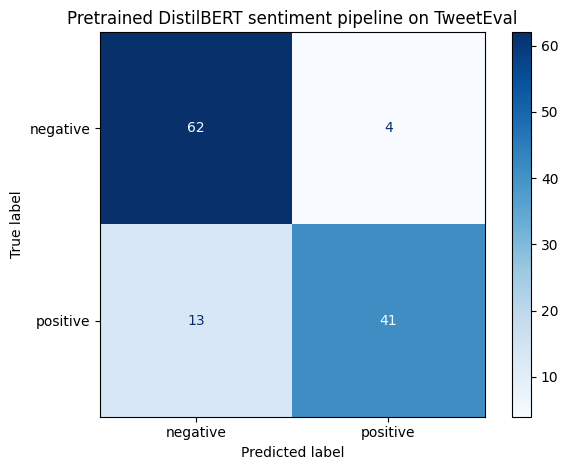

In [8]:
if RUN_PRETRAINED_PIPELINE:
    if not TRANSFORMERS_AVAILABLE:
        raise ImportError('Install transformers first: pip install -r materials/requirements-transformers.txt')

    from transformers import pipeline

    sentiment_model = pipeline(
        'sentiment-analysis',
        model='distilbert-base-uncased-finetuned-sst-2-english',
        truncation=True,
        device=-1
    )

    tweet_eval = pd.read_csv(DATA_DIR / 'tweet_eval_sentiment_sample.csv')
    pipe_sample = (
        tweet_eval[tweet_eval['label_name'].isin(['negative', 'positive'])]
        .sample(120, random_state=RANDOM_SEED)
        .copy()
    )
    outputs = sentiment_model(pipe_sample['text'].tolist(), batch_size=16)
    pipe_sample['transformer_label'] = [o['label'].lower() for o in outputs]
    pipe_sample['transformer_polarity'] = pipe_sample['transformer_label'].map({'positive': 'positive', 'negative': 'negative'})
    pipe_sample['transformer_score'] = [o['score'] for o in outputs]

    print(classification_report(pipe_sample['label_name'], pipe_sample['transformer_polarity']))
    ConfusionMatrixDisplay.from_predictions(pipe_sample['label_name'], pipe_sample['transformer_polarity'], cmap='Blues')
    plt.title('Pretrained DistilBERT sentiment pipeline on TweetEval')
    plt.tight_layout()
    display(pipe_sample[['text', 'label_name', 'transformer_polarity', 'transformer_score']].head())
else:
    print('Pretrained pipeline skipped. Set RUN_PRETRAINED_PIPELINE=True to run it.')

## 5. Frozen transformer features

A middle ground between feature engineering and fine-tuning is to use a transformer as a frozen feature extractor, then train a simple classifier on the resulting vectors. This is slower than TF-IDF but cheaper than full fine-tuning.

The transformer weights do not change. We mean-pool the contextual token representations and train logistic regression on those document vectors. The same training and test documents are used as in the TF-IDF baseline.

Frozen-feature device: mps


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 8165.37it/s]


[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


              precision    recall  f1-score   support

         ham       1.00      0.99      0.99       678
        spam       0.95      0.98      0.96        96

    accuracy                           0.99       774
   macro avg       0.97      0.99      0.98       774
weighted avg       0.99      0.99      0.99       774



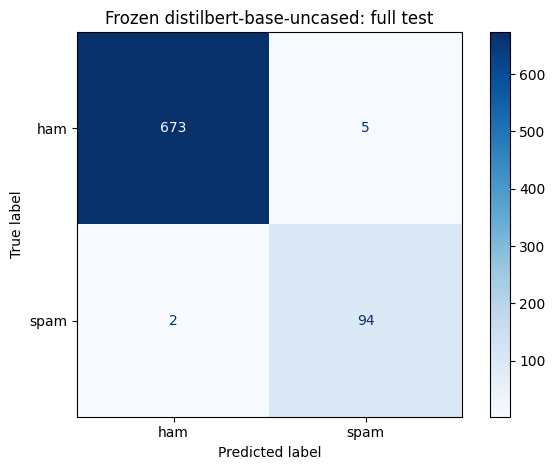

In [9]:
if RUN_FROZEN_FEATURES:
    if not (TRANSFORMERS_AVAILABLE and TORCH_AVAILABLE):
        raise ImportError('Install transformers and torch first.')

    import torch
    from transformers import AutoModel, AutoTokenizer

    if torch.cuda.is_available():
        feature_device = torch.device('cuda')
    elif torch.backends.mps.is_available():
        feature_device = torch.device('mps')
    else:
        feature_device = torch.device('cpu')
    print('Frozen-feature device:', feature_device)

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    encoder = AutoModel.from_pretrained(MODEL_NAME).to(feature_device)
    encoder.eval()

    def mean_pool(last_hidden_state, attention_mask):
        mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
        summed = (last_hidden_state * mask).sum(dim=1)
        counts = mask.sum(dim=1).clamp(min=1e-9)
        return summed / counts

    def encode_texts(texts, batch_size=16, max_length=128):
        vectors = []
        with torch.no_grad():
            for start in range(0, len(texts), batch_size):
                batch = texts[start:start + batch_size]
                enc = tokenizer(
                    batch,
                    padding=True,
                    truncation=True,
                    max_length=max_length,
                    return_tensors='pt'
                )
                enc = {key: value.to(feature_device) for key, value in enc.items()}
                out = encoder(**enc)
                pooled = mean_pool(out.last_hidden_state, enc['attention_mask'])
                vectors.append(pooled.cpu().numpy())
        return np.vstack(vectors)

    X_frozen_train = encode_texts(comparison_train['text'].tolist())
    X_frozen_full_test = encode_texts(comparison_test['text'].tolist())
    X_frozen_balanced_test = encode_texts(balanced_diagnostic_test['text'].tolist())

    frozen_clf = LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=RANDOM_SEED
    )
    frozen_clf.fit(X_frozen_train, comparison_train['label'])
    frozen_full_pred = frozen_clf.predict(X_frozen_full_test)
    frozen_balanced_pred = frozen_clf.predict(X_frozen_balanced_test)

    model_results.extend([
        result_row(
            f'Frozen {MODEL_NAME}',
            'full test',
            comparison_test['label'],
            frozen_full_pred
        ),
        result_row(
            f'Frozen {MODEL_NAME}',
            'balanced diagnostic test',
            balanced_diagnostic_test['label'],
            frozen_balanced_pred
        ),
    ])

    print(classification_report(
        comparison_test['label'],
        frozen_full_pred,
        target_names=['ham', 'spam']
    ))
    ConfusionMatrixDisplay.from_predictions(
        comparison_test['label'],
        frozen_full_pred,
        display_labels=['ham', 'spam'],
        cmap='Blues'
    )
    plt.title(f'Frozen {MODEL_NAME}: full test')
    plt.tight_layout()
else:
    print('Frozen feature extraction skipped. Set RUN_FROZEN_FEATURES=True to run it.')

## 6. Fine-tuning BERT/RoBERTa for sequence classification

Fine-tuning updates both the classifier head and the transformer weights for the target task. This is the core distinction from frozen features.

This cell uses Hugging Face `Trainer`, the full training split used by the other models, short sequences, and three epochs. Three validation observations are enough to make the learning-curve demonstration meaningful while still keeping the run manageable on a laptop.

When a base checkpoint is loaded for classification, Hugging Face reports that classifier-head weights are **missing** and newly initialized. This warning is expected: the base language model did not yet have a spam classifier. The new head is learned during fine-tuning.

Available accelerator: mps


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 9004.13it/s]


[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainer selected device: mps


...

fine-tuning elapsed seconds: 92.1


/Users/petrotolochko/miniconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


/Users/petrotolochko/miniconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


              precision    recall  f1-score   support

         ham       1.00      1.00      1.00       678
        spam       0.97      0.97      0.97        96

    accuracy                           0.99       774
   macro avg       0.98      0.98      0.98       774
weighted avg       0.99      0.99      0.99       774



,epoch,loss,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1
0,1.0,0.082936,NaN,NaN,NaN,NaN,NaN
1,1.0,NaN,0.049826,0.987080,0.967742,0.927835,0.947368
2,2.0,0.027062,NaN,NaN,NaN,NaN,NaN
3,2.0,NaN,0.046011,0.985788,0.947917,0.938144,0.943005
4,3.0,0.009446,NaN,NaN,NaN,NaN,NaN
5,3.0,NaN,0.058322,0.988372,0.968085,0.938144,0.952880
6,3.0,NaN,NaN,NaN,NaN,NaN,NaN


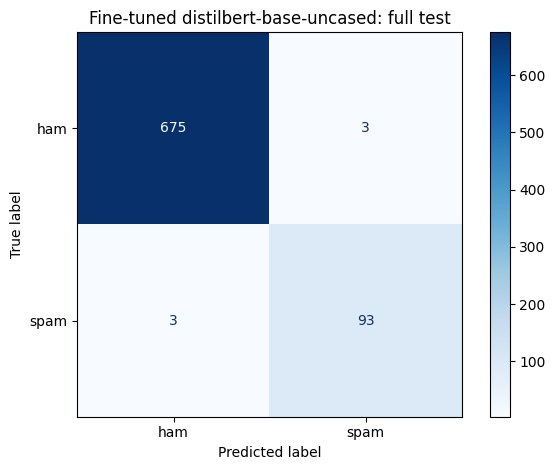

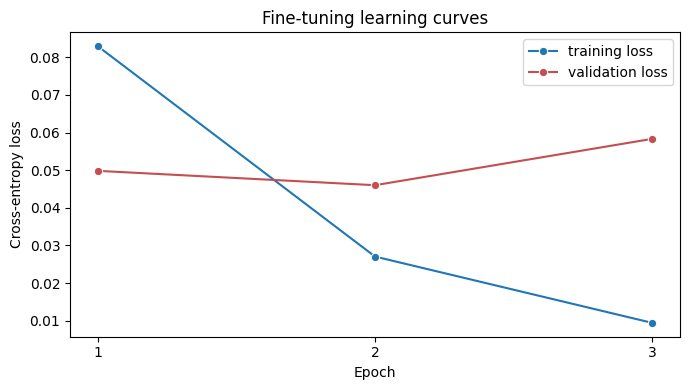

In [10]:
if RUN_FINE_TUNING:
    if not (TRANSFORMERS_AVAILABLE and TORCH_AVAILABLE):
        raise ImportError('Install the optional transformer stack first.')

    import inspect
    import torch
    from transformers import AutoModelForSequenceClassification, AutoTokenizer
    from transformers import DataCollatorWithPadding, Trainer, TrainingArguments

    if torch.cuda.is_available():
        detected_device = 'cuda'
    elif torch.backends.mps.is_available():
        detected_device = 'mps'
    else:
        detected_device = 'cpu'
    print('Available accelerator:', detected_device)

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

    class TextDataset(torch.utils.data.Dataset):
        def __init__(self, frame, tokenizer, max_length=128):
            self.labels = frame['label'].astype(int).tolist()
            self.encodings = tokenizer(
                frame['text'].tolist(),
                truncation=True,
                max_length=max_length
            )

        def __len__(self):
            return len(self.labels)

        def __getitem__(self, idx):
            item = {key: torch.tensor(value[idx]) for key, value in self.encodings.items()}
            item['labels'] = torch.tensor(self.labels[idx])
            return item

    train_dataset = TextDataset(comparison_train, tokenizer)
    valid_dataset = TextDataset(comparison_valid, tokenizer)
    full_test_dataset = TextDataset(comparison_test, tokenizer)
    balanced_test_dataset = TextDataset(balanced_diagnostic_test, tokenizer)

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2,
        id2label={0: 'ham', 1: 'spam'},
        label2id={'ham': 0, 'spam': 1}
    )

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = logits.argmax(axis=-1)
        precision, recall, f1, _ = precision_recall_fscore_support(
            labels, preds, average='binary', zero_division=0
        )
        acc = accuracy_score(labels, preds)
        return {'accuracy': acc, 'precision': precision, 'recall': recall, 'f1': f1}

    training_args_kwargs = {
        'output_dir': '../transformer_outputs/sms_spam_classifier',
        'learning_rate': 2e-5,
        'per_device_train_batch_size': 8,
        'per_device_eval_batch_size': 16,
        'num_train_epochs': 3,
        'weight_decay': 0.01,
        'logging_strategy': 'epoch',
        'save_strategy': 'epoch',
        'save_total_limit': 1,
        'load_best_model_at_end': True,
        'metric_for_best_model': 'f1',
        'greater_is_better': True,
        'seed': RANDOM_SEED,
        'data_seed': RANDOM_SEED,
        'report_to': []
    }
    training_arg_params = inspect.signature(TrainingArguments).parameters
    if 'eval_strategy' in training_arg_params:
        training_args_kwargs['eval_strategy'] = 'epoch'
    else:
        training_args_kwargs['evaluation_strategy'] = 'epoch'

    training_args = TrainingArguments(**training_args_kwargs)
    print('Trainer selected device:', training_args.device)

    trainer_kwargs = {
        'model': model,
        'args': training_args,
        'train_dataset': train_dataset,
        'eval_dataset': valid_dataset,
        'data_collator': data_collator,
        'compute_metrics': compute_metrics,
    }
    trainer_params = inspect.signature(Trainer).parameters
    if 'processing_class' in trainer_params:
        trainer_kwargs['processing_class'] = tokenizer
    else:
        trainer_kwargs['tokenizer'] = tokenizer

    trainer = Trainer(**trainer_kwargs)

    start = time.time()
    trainer.train()
    elapsed = time.time() - start
    print(f'fine-tuning elapsed seconds: {elapsed:.1f}')

    full_predictions = trainer.predict(full_test_dataset)
    full_logits = full_predictions.predictions
    fine_full_pred = full_logits.argmax(axis=-1)
    fine_full_true = comparison_test['label'].to_numpy()

    balanced_predictions = trainer.predict(balanced_test_dataset)
    fine_balanced_pred = balanced_predictions.predictions.argmax(axis=-1)
    fine_balanced_true = balanced_diagnostic_test['label'].to_numpy()

    model_results.extend([
        result_row(
            f'Fine-tuned {MODEL_NAME}',
            'full test',
            fine_full_true,
            fine_full_pred
        ),
        result_row(
            f'Fine-tuned {MODEL_NAME}',
            'balanced diagnostic test',
            fine_balanced_true,
            fine_balanced_pred
        ),
    ])

    print(classification_report(
        fine_full_true,
        fine_full_pred,
        target_names=['ham', 'spam']
    ))
    ConfusionMatrixDisplay.from_predictions(
        fine_full_true,
        fine_full_pred,
        display_labels=['ham', 'spam'],
        cmap='Blues'
    )
    plt.title(f'Fine-tuned {MODEL_NAME}: full test')
    plt.tight_layout()

    fine_tuning_history = pd.DataFrame(trainer.state.log_history)
    history_columns = [
        col for col in
        ['epoch', 'loss', 'eval_loss', 'eval_accuracy', 'eval_precision', 'eval_recall', 'eval_f1']
        if col in fine_tuning_history.columns
    ]
    display(fine_tuning_history[history_columns].dropna(how='all').tail(8))

    plt.figure(figsize=(7, 4))
    train_history = fine_tuning_history.dropna(subset=['loss'])
    validation_history = fine_tuning_history.dropna(subset=['eval_loss'])
    if not train_history.empty:
        sns.lineplot(
            data=train_history,
            x='epoch',
            y='loss',
            marker='o',
            label='training loss'
        )
    if not validation_history.empty:
        sns.lineplot(
            data=validation_history,
            x='epoch',
            y='eval_loss',
            marker='o',
            label='validation loss',
            color='#C44E52'
        )
    plt.title('Fine-tuning learning curves')
    plt.xlabel('Epoch')
    plt.ylabel('Cross-entropy loss')
    plt.xticks([1, 2, 3])
    plt.tight_layout()

    shifted_logits = full_logits - full_logits.max(axis=1, keepdims=True)
    full_probabilities = np.exp(shifted_logits)
    full_probabilities /= full_probabilities.sum(axis=1, keepdims=True)

    fine_tuning_errors = comparison_test[['text', 'class_name', 'label']].copy()
    fine_tuning_errors['predicted_label'] = fine_full_pred
    fine_tuning_errors['predicted_class'] = np.where(fine_full_pred == 1, 'spam', 'ham')
    fine_tuning_errors['confidence'] = full_probabilities.max(axis=1)
    fine_tuning_errors = (
        fine_tuning_errors[fine_tuning_errors['label'] != fine_tuning_errors['predicted_label']]
        .sort_values('confidence', ascending=False)
        [['text', 'class_name', 'predicted_class', 'confidence']]
        .reset_index(drop=True)
    )
else:
    print('Fine-tuning skipped. Set RUN_FINE_TUNING=True to run it.')

## 7. Fair model comparison and error analysis

Because every model used the same full training split and the same test documents, differences in this table reflect the modeling approach rather than different data.

The full test set retains the dataset's natural spam prevalence. The balanced diagnostic test is useful for asking a different question: conditional on seeing equal numbers of ham and spam messages, how cleanly does the model separate the two classes? Compare spam precision, recall, and F1, then inspect the fine-tuned model's most confident mistakes. Confident errors are especially useful for detecting ambiguous labels, domain shortcuts, and systematic blind spots.

,model,evaluation_set,n_test,spam_prevalence,accuracy,precision_spam,recall_spam,f1_spam
0,Frozen distilbert-base-uncased,balanced diagnostic test,192,50.0%,0.990,1.000,0.979,0.989
1,Fine-tuned distilbert-base-uncased,balanced diagnostic test,192,50.0%,0.984,1.000,0.969,0.984
2,TF-IDF + logistic regression,balanced diagnostic test,192,50.0%,0.958,0.989,0.927,0.957
3,Fine-tuned distilbert-base-uncased,full test,774,12.4%,0.992,0.969,0.969,0.969
4,Frozen distilbert-base-uncased,full test,774,12.4%,0.991,0.949,0.979,0.964
5,TF-IDF + logistic regression,full test,774,12.4%,0.978,0.899,0.927,0.913


Fine-tuned model errors on full test: 6


,text,class_name,predicted_class,confidence
0,Total video converter free download type this in google search:),ham,spam,0.998425
1,"Im in inperialmusic listening2the weirdest track ever byleafcutter john-sounds like insects being molested&someone plumbing,remixed by evil men on acid!",ham,spam,0.916127
2,"Xmas & New Years Eve tickets are now on sale from the club, during the day from 10am till 8pm, and on Thurs, Fri & Sat night this week. They're selling fast!",spam,ham,0.710965
3,Guess who am I?This is the first time I created a web page WWW.ASJESUS.COM read all I wrote. I'm waiting for your opinions. I want to be your friend 1/1,spam,ham,0.689764
4,Double eviction this week - Spiral and Michael and good riddance to them!,ham,spam,0.655553
5,TheMob>Yo yo yo-Here comes a new selection of hot downloads for our members to get for FREE! Just click & open the next link sent to ur fone...,spam,ham,0.611500


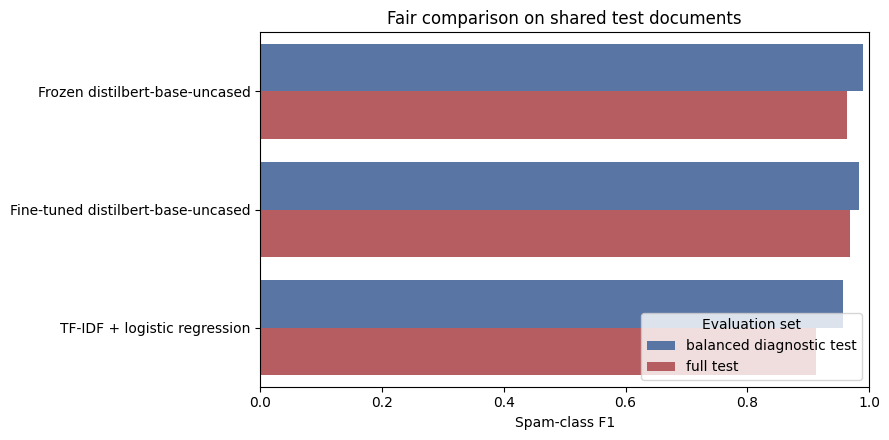

In [11]:
comparison_results = (
    pd.DataFrame(model_results)
    .sort_values(['evaluation_set', 'f1_spam'], ascending=[True, False])
    .reset_index(drop=True)
)
display(
    comparison_results.style.format({
        'spam_prevalence': '{:.1%}',
        'accuracy': '{:.3f}',
        'precision_spam': '{:.3f}',
        'recall_spam': '{:.3f}',
        'f1_spam': '{:.3f}',
    })
)

plt.figure(figsize=(9, 4.5))
sns.barplot(
    data=comparison_results,
    x='f1_spam',
    y='model',
    hue='evaluation_set',
    palette=['#4C72B0', '#C44E52']
)
plt.xlim(0, 1)
plt.xlabel('Spam-class F1')
plt.ylabel('')
plt.title('Fair comparison on shared test documents')
plt.legend(title='Evaluation set', loc='lower right')
plt.tight_layout()

if 'fine_tuning_errors' in globals():
    print(f'Fine-tuned model errors on full test: {len(fine_tuning_errors)}')
    display(fine_tuning_errors.head(10))
else:
    print('Enable RUN_FINE_TUNING to generate the confident-error table.')

## 8. Switching from DistilBERT to BERT or RoBERTa

The training logic stays the same. The model name changes the tokenizer, pretrained weights, and architecture.

Try these values:

```python
MODEL_NAME = 'bert-base-uncased'
MODEL_NAME = 'roberta-base'
```

Practical differences to discuss:

- BERT uses WordPiece; RoBERTa uses byte-level BPE.
- RoBERTa was trained with different pretraining choices than BERT.
- Larger models usually need more memory and time.
- A bigger model is not automatically a better measurement instrument.

For a proper comparison, rerun the notebook from the top so every model sees the same split, and record runtime as well as predictive performance.

In [12]:
model_comparison_plan = pd.DataFrame([
    {
        'model': 'distilbert-base-uncased',
        'why_use_it': 'fast classroom demo; smaller BERT-style model',
        'main_cost': 'less capacity than BERT/RoBERTa'
    },
    {
        'model': 'bert-base-uncased',
        'why_use_it': 'canonical BERT baseline',
        'main_cost': 'slower and heavier than DistilBERT'
    },
    {
        'model': 'roberta-base',
        'why_use_it': 'strong BERT-family encoder with different tokenizer/pretraining',
        'main_cost': 'heavier; tokenizer behavior differs'
    }
])

model_comparison_plan

,model,why_use_it,main_cost
0,distilbert-base-uncased,fast classroom demo; smaller BERT-style model,less capacity than BERT/RoBERTa
1,bert-base-uncased,canonical BERT baseline,slower and heavier than DistilBERT
2,roberta-base,strong BERT-family encoder with different tokenizer/pretraining,heavier; tokenizer behavior differs


## 9. Reporting checklist for transformer classification

A paper or replication package should report:

- Exact model checkpoint, e.g. `bert-base-uncased` or `roberta-base`.
- Tokenizer and maximum sequence length.
- Train/validation/test split construction and duplicate handling.
- Number of examples and class balance.
- Hyperparameters: learning rate, batch size, epochs, weight decay.
- Checkpoint-selection rule.
- Hardware and approximate training time.
- Random seed and sensitivity across repeated runs.
- Validation metrics and error analysis.
- Whether the model was evaluated under natural class prevalence and out of domain.
- Whether labels validly measure the construct.

## 10. Student task

Choose one of these tasks:

1. Run the pretrained sentiment pipeline and explain why it is a different task from SMS spam detection.
2. Compare TF-IDF, frozen DistilBERT features, and fine-tuned DistilBERT on the shared full test set.
3. Repeat fine-tuning with `bert-base-uncased` or `roberta-base` and compare performance, runtime, learning curves, and errors.
4. Explain why accuracy and spam-class F1 differ between the full test set and the balanced diagnostic test.
5. Write a short validation memo: did the transformer improve prediction, measurement validity, both, or neither?